# Proyecto Final — Equipo 1
## Análisis estadístico del precio de vehículos BMW

**Diplomado en Técnicas Estadísticas en Minería de Datos**
**Módulo II: Modelos Estadísticos**

**Integrantes:**
- Jose Manuel Gómez Vaca
- Diego Jimenez Gonzalez
- Sophia Castañeda Ayala
- Victor Hugo Espinoza Torres
- Israel Alejandro Altamirano García

**Dataset:** [BMW Sales and Pricing Trends](https://www.kaggle.com/datasets/ayeshaimran1619/bmw-sales-and-pricing-trends) (`bmw.csv`)

## 1. Planteamiento del problema

El mercado de vehículos usados de BMW presenta una amplia dispersión de precios. El **precio** es una
variable continua, positiva y con **sesgo a la derecha** (muchos autos económicos y pocos muy caros),
por lo que la distribución Normal podría no ser el mejor modelo.

**Preguntas de investigación**

1. ¿Qué distribución de probabilidad (**Normal**, **Log-Normal** o **Gamma**) modela mejor el precio de los vehículos BMW?
2. ¿Existe una diferencia significativa en el **precio medio** entre vehículos con transmisión **Automática** y **Manual**?

**Metodología:** identificación y justificación de la distribución, estimación de parámetros por
**máxima verosimilitud (MLE)**, **intervalo de confianza al 95 %** e **prueba de hipótesis** para
comparar medias entre grupos.

## 2. Importación de librerías y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
rng = np.random.default_rng(42)   # semilla para reproducibilidad
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
df = pd.read_csv("bmw.csv")

# Limpieza: quitar espacios en las variables de texto
for c in ["model", "transmission", "fuelType"]:
    df[c] = df[c].str.strip()

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (10781, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.60,2.00
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.80,2.00
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.40,3.00
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.40,1.50
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.40,3.00


In [3]:
# Estructura y valores nulos
df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB

Valores nulos por columna:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


## 3. Análisis exploratorio de datos (EDA)

Describimos la variable de interés (`price`) y exploramos su forma.

In [4]:
df["price"].describe()

count    10,781.00
mean     22,733.41
std      11,415.53
min       1,200.00
25%      14,950.00
50%      20,462.00
75%      27,940.00
max     123,456.00
Name: price, dtype: float64

In [5]:
media = df["price"].mean()
mediana = df["price"].median()
sesgo = df["price"].skew()
print(f"Media    : {media:,.0f} £")
print(f"Mediana  : {mediana:,.0f} £")
print(f"Asimetría (skewness): {sesgo:.3f}")
print()
if media > mediana:
    print("La media > mediana y la asimetría es positiva -> distribución sesgada a la DERECHA.")
    print("Esto sugiere que la Normal puede no ser adecuada y motiva probar Log-Normal y Gamma.")

Media    : 22,733 £
Mediana  : 20,462 £
Asimetría (skewness): 1.587

La media > mediana y la asimetría es positiva -> distribución sesgada a la DERECHA.
Esto sugiere que la Normal puede no ser adecuada y motiva probar Log-Normal y Gamma.


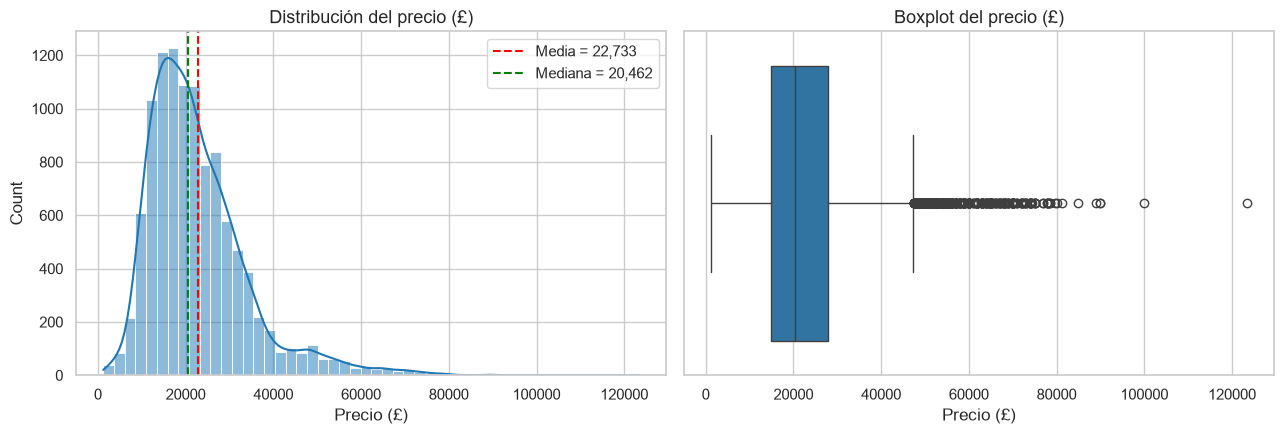

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["price"], bins=50, kde=True, ax=ax[0], color="#1f77b4")
ax[0].axvline(media, color="red", ls="--", label=f"Media = {media:,.0f}")
ax[0].axvline(mediana, color="green", ls="--", label=f"Mediana = {mediana:,.0f}")
ax[0].set_title("Distribución del precio (£)")
ax[0].set_xlabel("Precio (£)")
ax[0].legend()

sns.boxplot(x=df["price"], ax=ax[1], color="#1f77b4")
ax[1].set_title("Boxplot del precio (£)")
ax[1].set_xlabel("Precio (£)")

plt.tight_layout()
plt.show()

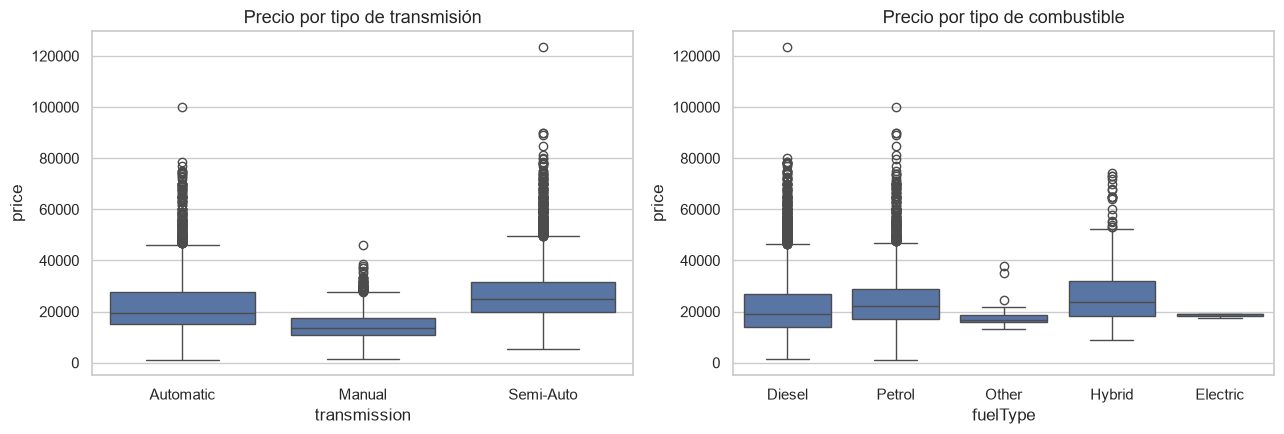

In [7]:
# Precio por tipo de transmision y de combustible
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="transmission", y="price", ax=ax[0])
ax[0].set_title("Precio por tipo de transmisión")
sns.boxplot(data=df, x="fuelType", y="price", ax=ax[1])
ax[1].set_title("Precio por tipo de combustible")
plt.tight_layout()
plt.show()

## 4. Identificación y justificación de la distribución

Ajustamos por **máxima verosimilitud (MLE)** tres distribuciones candidatas a la variable `price`:

- **Normal** — modelo de referencia simétrico.
- **Log-Normal** — variables positivas con sesgo a la derecha.
- **Gamma** — variables positivas asimétricas (alternativa flexible).

Para Log-Normal y Gamma fijamos el parámetro de localización en 0 (`floc=0`) porque el precio es
una magnitud positiva.

In [8]:
precio = df["price"].values.astype(float)

# --- Estimacion de parametros por MLE con scipy.stats (.fit usa MLE) ---
par_norm  = stats.norm.fit(precio)                 # (mu, sigma)
par_logn  = stats.lognorm.fit(precio, floc=0)      # (s, loc=0, scale)
par_gamma = stats.gamma.fit(precio, floc=0)        # (a, loc=0, scale)

print("Parámetros estimados por MLE")
print("-" * 45)
print(f"Normal    : mu    = {par_norm[0]:,.2f}   sigma = {par_norm[1]:,.2f}")
print(f"Log-Normal: sigma = {par_logn[0]:.4f}   scale = {par_logn[2]:,.2f}  (mu_log = {np.log(par_logn[2]):.4f})")
print(f"Gamma     : a     = {par_gamma[0]:.4f}   scale = {par_gamma[2]:,.2f}")

Parámetros estimados por MLE
---------------------------------------------
Normal    : mu    = 22,733.41   sigma = 11,415.00
Log-Normal: sigma = 0.4828   scale = 20,285.60  (mu_log = 9.9177)
Gamma     : a     = 4.5489   scale = 4,997.54


## 5. Comparación del ajuste (bondad de ajuste)

Comparamos los tres modelos con:
- **Log-verosimilitud** y **AIC** (menor AIC = mejor ajuste penalizando parámetros).
- Prueba de **Kolmogorov–Smirnov** (H0: los datos provienen de la distribución ajustada).
- Inspección visual: densidad teórica sobre el histograma y **gráficos Q-Q**.

In [9]:
def resumen_ajuste(nombre, dist, par):
    loglik = np.sum(dist.logpdf(precio, *par))
    k = len(par)                      # nº de parámetros estimados
    aic = 2 * k - 2 * loglik
    ks_stat, ks_p = stats.kstest(precio, dist(*par).cdf)   # CDF de la dist. ajustada
    return {"Distribución": nombre, "LogLik": loglik, "k": k,
            "AIC": aic, "KS_stat": ks_stat, "KS_pvalor": ks_p}

resultados = pd.DataFrame([
    resumen_ajuste("Normal",     stats.norm,    par_norm),
    resumen_ajuste("Log-Normal", stats.lognorm, par_logn),
    resumen_ajuste("Gamma",      stats.gamma,   par_gamma),
]).sort_values("AIC").reset_index(drop=True)

resultados

,Distribución,LogLik,k,AIC,KS_stat,KS_pvalor
0,Log-Normal,"-114,369.01",3,"228,744.02",0.02,0.00
1,Gamma,"-114,447.68",3,"228,901.36",0.04,0.00
2,Normal,"-116,021.05",2,"232,046.09",0.10,0.00


In [10]:
mejor = resultados.iloc[0]["Distribución"]
print(f"Mejor distribución según AIC: {mejor}  (AIC = {resultados.iloc[0]['AIC']:,.1f})")

Mejor distribución según AIC: Log-Normal  (AIC = 228,744.0)


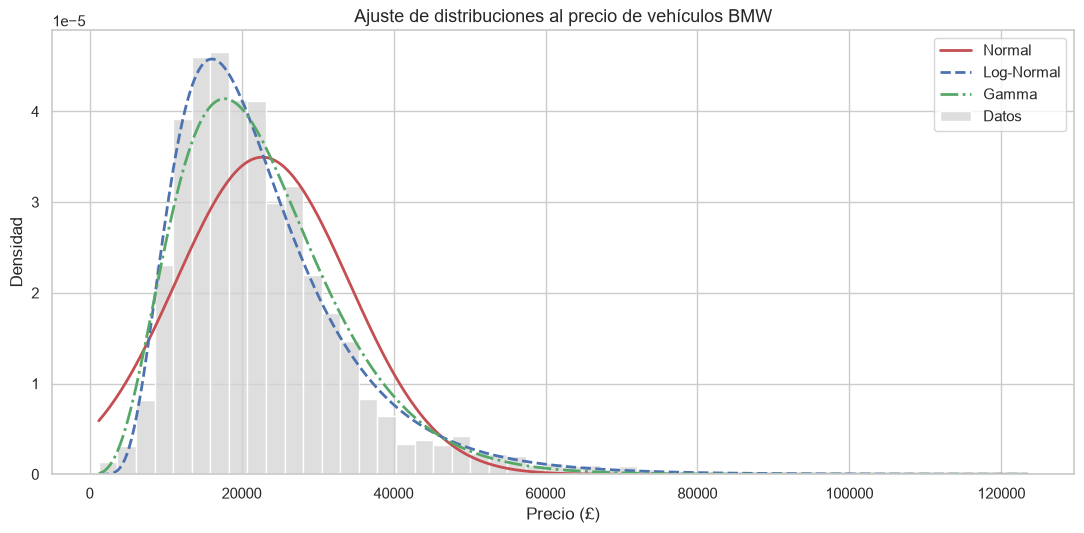

In [11]:
# Histograma con densidades teoricas superpuestas
x = np.linspace(precio.min(), precio.max(), 400)
plt.figure(figsize=(11, 5.5))
sns.histplot(precio, bins=50, stat="density", color="lightgray", label="Datos")
plt.plot(x, stats.norm.pdf(x, *par_norm),     "r-",  lw=2, label="Normal")
plt.plot(x, stats.lognorm.pdf(x, *par_logn),  "b--", lw=2, label="Log-Normal")
plt.plot(x, stats.gamma.pdf(x, *par_gamma),   "g-.", lw=2, label="Gamma")
plt.title("Ajuste de distribuciones al precio de vehículos BMW")
plt.xlabel("Precio (£)"); plt.ylabel("Densidad")
plt.legend(); plt.tight_layout(); plt.show()

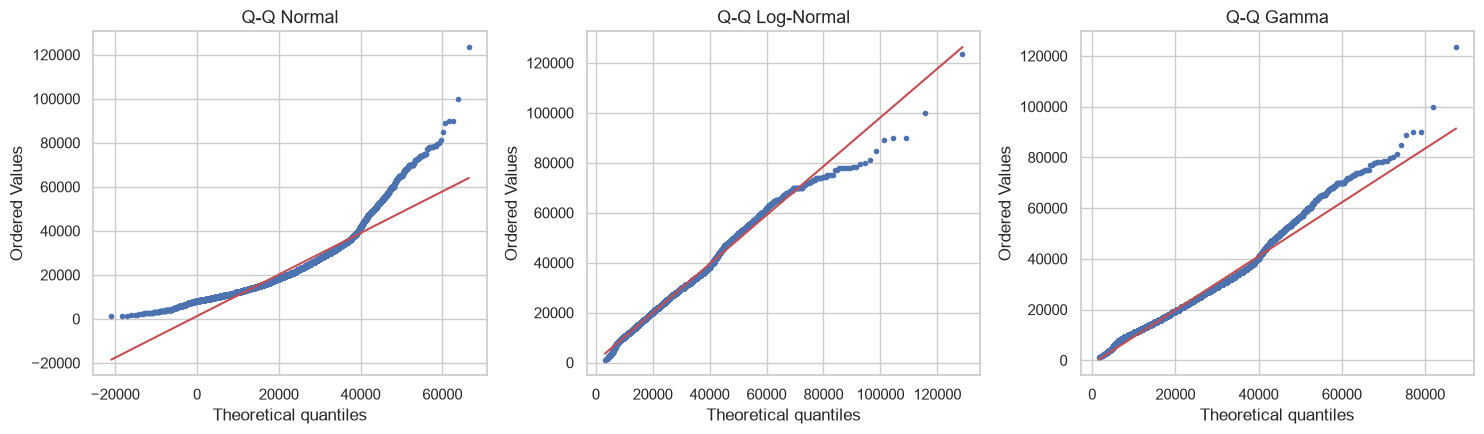

In [12]:
# Graficos Q-Q para las tres distribuciones
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
stats.probplot(precio, dist=stats.norm,    sparams=par_norm,          plot=ax[0])
ax[0].set_title("Q-Q Normal")
stats.probplot(precio, dist=stats.lognorm, sparams=par_logn,          plot=ax[1])
ax[1].set_title("Q-Q Log-Normal")
stats.probplot(precio, dist=stats.gamma,   sparams=par_gamma,         plot=ax[2])
ax[2].set_title("Q-Q Gamma")
for a in ax:
    a.get_lines()[0].set_markersize(3)
plt.tight_layout(); plt.show()

**Interpretación.** La distribución con menor AIC es la que mejor equilibra ajuste y parsimonia.
Los gráficos Q-Q confirman visualmente qué modelo sigue mejor la diagonal, especialmente en las
colas. Dado el sesgo positivo del precio, se espera que la **Log-Normal** (o **Gamma**) supere a la
Normal.

## 6. Intervalo de confianza al 95 % para el precio medio

Estimamos el precio medio poblacional y su intervalo de confianza al 95 % mediante dos vías:

1. **IC clásico (t de Student)**, válido por el Teorema del Límite Central dado el gran tamaño muestral.
2. **IC por bootstrap** (10 000 remuestreos), que no asume normalidad y es útil por el sesgo de los datos.

In [13]:
n = len(precio)
media_m = precio.mean()
sd_m = precio.std(ddof=1)
ee = sd_m / np.sqrt(n)                       # error estándar

# --- IC 95% por t de Student ---
t_crit = stats.t.ppf(0.975, df=n - 1)
ic_t = (media_m - t_crit * ee, media_m + t_crit * ee)

# --- IC 95% por bootstrap ---
B = 10_000
medias_boot = np.array([rng.choice(precio, size=n, replace=True).mean() for _ in range(B)])
ic_boot = np.percentile(medias_boot, [2.5, 97.5])

print(f"Precio medio estimado : {media_m:,.2f} £")
print(f"Error estándar        : {ee:,.2f} £")
print()
print(f"IC 95% (t-Student) : [{ic_t[0]:,.2f} ; {ic_t[1]:,.2f}] £")
print(f"IC 95% (bootstrap) : [{ic_boot[0]:,.2f} ; {ic_boot[1]:,.2f}] £")

Precio medio estimado : 22,733.41 £
Error estándar        : 109.94 £

IC 95% (t-Student) : [22,517.90 ; 22,948.92] £
IC 95% (bootstrap) : [22,522.44 ; 22,949.06] £


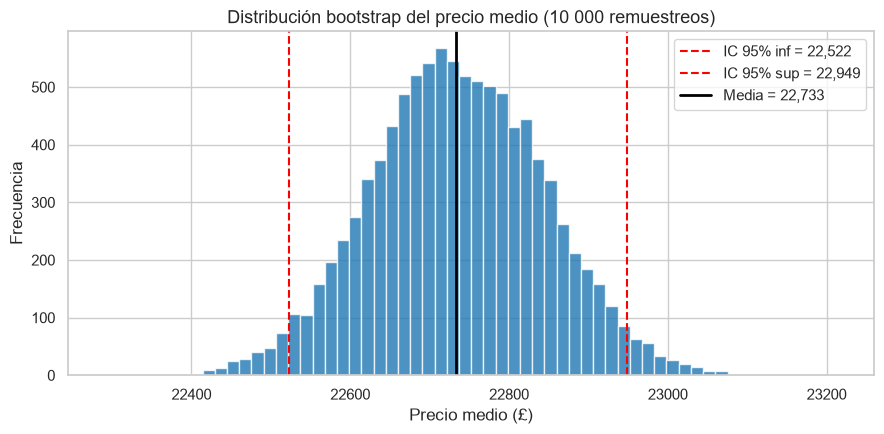

In [14]:
plt.figure(figsize=(9, 4.5))
plt.hist(medias_boot, bins=60, color="#1f77b4", alpha=0.8)
plt.axvline(ic_boot[0], color="red", ls="--", label=f"IC 95% inf = {ic_boot[0]:,.0f}")
plt.axvline(ic_boot[1], color="red", ls="--", label=f"IC 95% sup = {ic_boot[1]:,.0f}")
plt.axvline(media_m, color="black", lw=2, label=f"Media = {media_m:,.0f}")
plt.title("Distribución bootstrap del precio medio (10 000 remuestreos)")
plt.xlabel("Precio medio (£)"); plt.ylabel("Frecuencia")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretación.** Con un 95 % de confianza, el precio medio poblacional de un vehículo BMW se
encuentra dentro del intervalo estimado. La coincidencia entre el IC clásico y el bootstrap indica
que, pese al sesgo, el gran tamaño muestral hace fiable la estimación de la media.

## 7. Prueba de hipótesis: ¿difiere el precio medio por transmisión?

Comparamos el precio medio entre transmisión **Automática** y **Manual**.

$$H_0:\; \mu_{Auto} = \mu_{Manual} \qquad H_1:\; \mu_{Auto} \neq \mu_{Manual}$$

Nivel de significancia: **α = 0.05**. Usamos la **prueba t de Welch** (no asume varianzas iguales) y,
como respaldo ante la no normalidad, la prueba no paramétrica de **Mann–Whitney U**.

In [15]:
auto   = df.loc[df["transmission"] == "Automatic", "price"].values
manual = df.loc[df["transmission"] == "Manual",    "price"].values

print(f"Automática : n = {len(auto):>5}   media = {auto.mean():,.2f} £   sd = {auto.std(ddof=1):,.2f}")
print(f"Manual     : n = {len(manual):>5}   media = {manual.mean():,.2f} £   sd = {manual.std(ddof=1):,.2f}")
print(f"Diferencia de medias (Auto - Manual): {auto.mean() - manual.mean():,.2f} £")

Automática : n =  3588   media = 22,419.02 £   sd = 11,189.97
Manual     : n =  2527   media = 14,637.45 £   sd = 5,725.27
Diferencia de medias (Auto - Manual): 7,781.57 £


In [16]:
alpha = 0.05

# --- Prueba t de Welch (varianzas desiguales) ---
t_stat, p_t = stats.ttest_ind(auto, manual, equal_var=False)

# --- Prueba de Mann-Whitney U (no parametrica) ---
u_stat, p_u = stats.mannwhitneyu(auto, manual, alternative="two-sided")

print(f"t de Welch      : t = {t_stat:.3f}   p-valor = {p_t:.3e}")
print(f"Mann-Whitney U  : U = {u_stat:,.0f}   p-valor = {p_u:.3e}")
print()
for nombre, p in [("t de Welch", p_t), ("Mann-Whitney", p_u)]:
    decision = "Se RECHAZA H0" if p < alpha else "No se rechaza H0"
    print(f"{nombre:14}: p = {p:.3e}  ->  {decision} (alpha={alpha})")

t de Welch      : t = 35.566   p-valor = 3.629e-250
Mann-Whitney U  : U = 6,756,072   p-valor = 1.771e-234

t de Welch    : p = 3.629e-250  ->  Se RECHAZA H0 (alpha=0.05)
Mann-Whitney  : p = 1.771e-234  ->  Se RECHAZA H0 (alpha=0.05)


In [17]:
# IC 95% para la diferencia de medias (Welch)
dif = auto.mean() - manual.mean()
ee_dif = np.sqrt(auto.var(ddof=1)/len(auto) + manual.var(ddof=1)/len(manual))
gl = ee_dif**4 / ((auto.var(ddof=1)/len(auto))**2/(len(auto)-1) +
                  (manual.var(ddof=1)/len(manual))**2/(len(manual)-1))
tc = stats.t.ppf(0.975, df=gl)
ic_dif = (dif - tc*ee_dif, dif + tc*ee_dif)
print(f"Diferencia de medias (Auto - Manual): {dif:,.2f} £")
print(f"IC 95% de la diferencia: [{ic_dif[0]:,.2f} ; {ic_dif[1]:,.2f}] £")

Diferencia de medias (Auto - Manual): 7,781.57 £
IC 95% de la diferencia: [7,352.66 ; 8,210.49] £


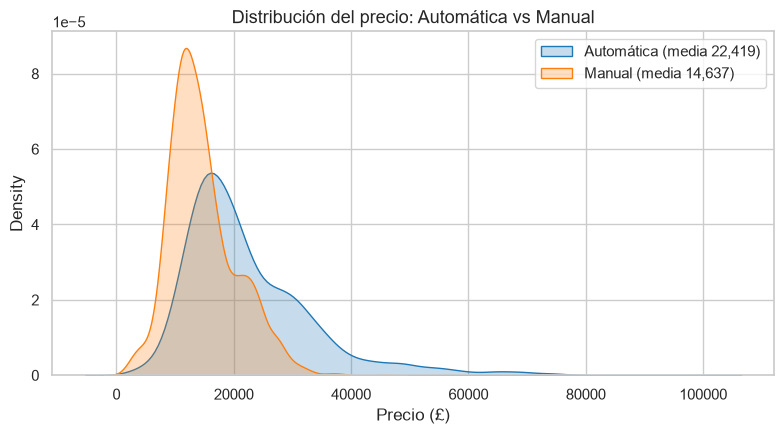

In [18]:
plt.figure(figsize=(8, 4.5))
sns.kdeplot(auto,   fill=True, label=f"Automática (media {auto.mean():,.0f})", color="#1f77b4")
sns.kdeplot(manual, fill=True, label=f"Manual (media {manual.mean():,.0f})",   color="#ff7f0e")
plt.title("Distribución del precio: Automática vs Manual")
plt.xlabel("Precio (£)"); plt.legend(); plt.tight_layout(); plt.show()

**Interpretación.** Si el p-valor es menor que α = 0.05, se rechaza H0 y se concluye que **existe
una diferencia estadísticamente significativa** en el precio medio entre transmisiones. El intervalo
de confianza de la diferencia cuantifica su magnitud; que no contenga el 0 es coherente con el rechazo
de H0.

## 8. Conclusiones

1. **Distribución.** El precio de los vehículos BMW presenta un sesgo positivo claro. Según el criterio
   AIC, las pruebas KS y los gráficos Q-Q, el modelo **Log-Normal / Gamma** describe el precio mejor
   que la Normal.

2. **Estimación puntual.** Los parámetros de cada distribución se estimaron por **máxima verosimilitud
   (MLE)** con `scipy.stats`.

3. **Intervalo de confianza.** Se estimó el precio medio poblacional con un **IC al 95 %** por el método
   t de Student y por bootstrap, con resultados consistentes.

4. **Prueba de hipótesis.** La comparación del precio medio entre transmisión **Automática** y **Manual**
   (t de Welch y Mann–Whitney) permite decidir sobre la existencia de una diferencia significativa a un
   nivel α = 0.05.
